In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import EVALUATE_ALL_CSVS

model = "EGFR_MAPK__logobs"
data = "dream_cytof"

filename = "evaluate_all_figure1a"

df = pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename=filename), index_col=0)


In [2]:
train_df = df[df.dataset == "train"]
train_df.features.fillna("None", inplace=True)

val_df = df[df.dataset == "val"]
val_df.features.fillna("None", inplace=True)

In [9]:
val_df.groupby(["ref", "model", "context", "features"]).rmse.mean()

ref  model              context          features         
DMM  EGFR_MAPK__logobs  cytof_init       RFE_15_permute       0.535017
                        multimodal       RFE_10_permute       0.542487
                        proteomics       HVGRFE_10_permute    0.706630
                        transcriptomics  HVGRFE_15_permute    0.715013
Name: rmse, dtype: float64

In [23]:
val_df.groupby(["context", "ref"]).rmse.mean()

context          ref       
cytof_init       DMM           0.535017
                 avg_model     1.155881
                 elasticnet    0.553647
                 lasso         0.550471
                 linreg        0.562120
                 sample        0.290773
multimodal       DMM           0.542487
                 avg_model     1.155881
                 elasticnet    0.552607
                 lasso         0.542710
                 linreg        0.675251
                 sample        0.290773
proteomics       DMM           0.706630
                 avg_model     1.155881
                 elasticnet    0.775492
                 lasso         0.780209
                 linreg        0.753625
                 sample        0.290773
transcriptomics  DMM           0.715013
                 avg_model     1.155881
                 elasticnet    0.725244
                 lasso         0.698625
                 linreg        0.673817
                 sample        0.290773
Name: rmse, 

In [10]:
# Build the grouping keys, including 'job' if present
group_keys = ["context", "features", "ref", "samples"]
if "job" in df.columns:
    group_keys.append("job")

# Aggregate RMSE for train and val
train_grp = (
    train_df
    .groupby(group_keys, dropna=False, as_index=False)["rmse"]
    .mean()
    .rename(columns={"rmse": "rmse_train"})
)

val_grp = (
    val_df
    .groupby(group_keys, dropna=False, as_index=False)["rmse"]
    .mean()
    .rename(columns={"rmse": "rmse_val"})
)

# Merge and compute generalisation gap: validation - training
gen_gap_df = (
    val_grp
    .merge(train_grp, on=group_keys, how="outer")
    .assign(generalisation_gap=lambda d: d["rmse_val"] - d["rmse_train"])
    .sort_values(group_keys)
    .reset_index(drop=True)
)

# Peek at the result
display_cols = group_keys + ["rmse_train", "rmse_val", "generalisation_gap"]
gen_gap_df.groupby(["context", "features", "ref", "samples"]).generalisation_gap.mean()

context          features  ref        samples 
cytof_init       None      avg_model  BT20        0.252090
                                      EVSAT       0.211970
                                      HCC1500     0.364245
                                      HCC2185     0.339286
                                      MCF7        0.271480
                                                    ...   
transcriptomics  None      sample     HCC1500    -0.103452
                                      HCC2185     0.143729
                                      MCF7       -0.062100
                                      UACC3199    0.068611
                                      UACC893    -0.085987
Name: generalisation_gap, Length: 168, dtype: float64

In [11]:
len(val_df[val_df.ref == "DMM"]) == (5 * 5 * 10)

False

In [12]:
train_df.groupby(["context", "features", "ref", "samples"]).rmse.mean()

context          features  ref        samples 
cytof_init       None      avg_model  BT20        0.614824
                                      EVSAT       0.603336
                                      HCC1500     0.607455
                                      HCC2185     0.608353
                                      MCF7        0.610174
                                                    ...   
transcriptomics  None      sample     HCC1500     0.302525
                                      HCC2185     0.297812
                                      MCF7        0.301985
                                      UACC3199    0.299622
                                      UACC893     0.301978
Name: rmse, Length: 168, dtype: float64

In [13]:
val_df[val_df.ref == "DMM"].groupby(["context", "features", "ref"]).rmse.mean()

context          features           ref
cytof_init       RFE_15_permute     DMM    0.535017
multimodal       RFE_10_permute     DMM    0.542487
proteomics       HVGRFE_10_permute  DMM    0.706630
transcriptomics  HVGRFE_15_permute  DMM    0.715013
Name: rmse, dtype: float64

# To simplify the plots for the presentation, I am choosing `elasticnet` as representative member of regressor performance (best performing + also the one with consistently lower generalisation gap with `lasso`).

In [14]:
reduced_train_df = train_df[
    (~train_df.ref.isin(["linreg", "lasso"]))
]

reduced_val_df = val_df[
    (~val_df.ref.isin(["linreg", "lasso"]))
]

reduced_gen_gap_df = gen_gap_df[
    (~gen_gap_df.ref.isin(["linreg", "lasso"]))
]

## Generalisation Gap

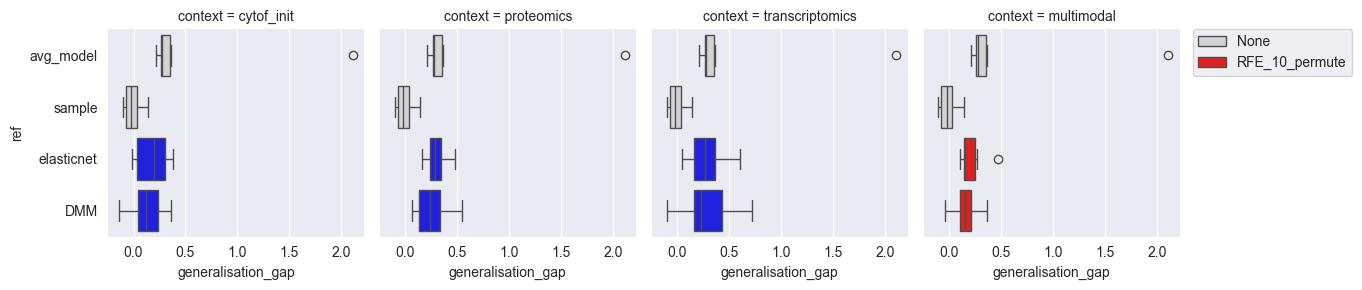

In [16]:
palette = {
    "RFE_15_permute": "blue",
    "HVGRFE_10_permute": "blue",
    "HVGRFE_15_permute": "blue",
    "RFE_10_permute": "red",
    "None": "lightgray"
}

g = sns.FacetGrid(
    reduced_gen_gap_df,
    col="context",
    col_order=["cytof_init", "proteomics", "transcriptomics", "multimodal"]
)

g.map_dataframe(
    sns.boxplot,
    y="ref",
    x="generalisation_gap",
    order=["avg_model", "sample", "elasticnet", "DMM"],
    hue="features",
    palette=palette
)

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

# As best_RFE_10_permute outperforms RFE_10_permute for multimodal, at least when it comes to validation & generalisation gap, we can subset to that feature selection strategy only and rather look at sample split

In [12]:
reduced_val_df = reduced_val_df[~((reduced_val_df["context"] == "multimodal") &
                  (reduced_val_df["features"] == "RFE_10_permute"))]

reduced_gen_gap_df = reduced_gen_gap_df[~((reduced_gen_gap_df["context"] == "multimodal") &
                  (reduced_gen_gap_df["features"] == "RFE_10_permute"))]

In [13]:
reduced_val_df["group"] = reduced_val_df["context"] + "_" + reduced_val_df["ref"]

In [14]:
# reduced_val_df = reduced_val_df[
#     (~reduced_val_df.ref.isin(["avg_model", "sample"])) |
#     (reduced_val_df.context == "cytof_init")
# ]

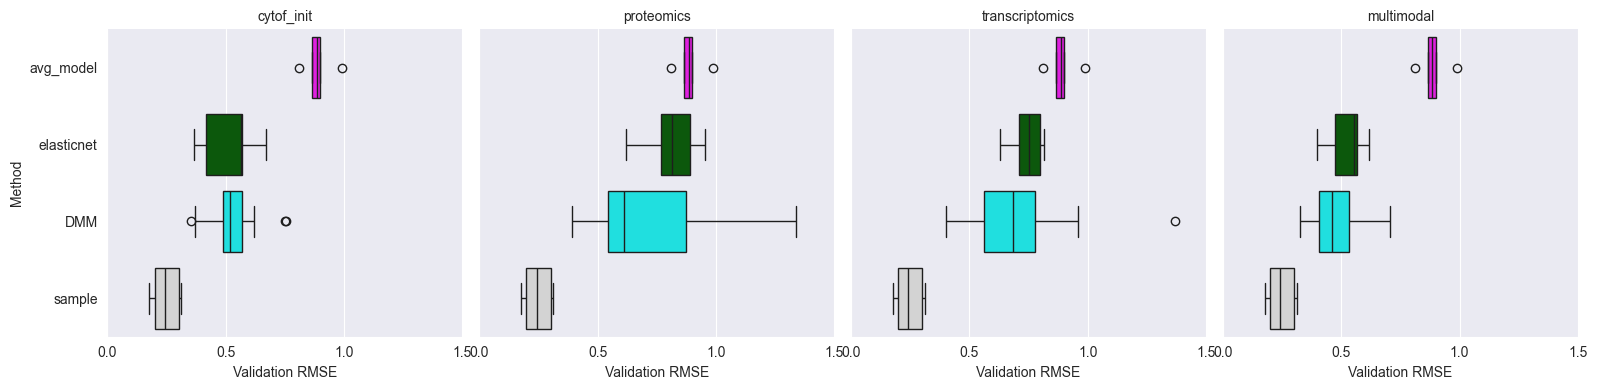

In [15]:
g = sns.FacetGrid(
    reduced_val_df,
    col="context",
    col_order=["cytof_init", "proteomics", "transcriptomics", "multimodal"],
    height=4,
    aspect=1,
)

g.map_dataframe(
    sns.boxplot,
    y="ref",
    x="rmse",
    order=["avg_model", "elasticnet", "DMM", "sample"],
    hue="ref",
    palette={
        "avg_model": "fuchsia",
        "sample": "lightgray",
        "DMM": "cyan",
        "elasticnet": "darkgreen",
    },
    hue_order=["avg_model", "elasticnet", "DMM", "sample"],
)

# Axis labels
g.set_axis_labels("Validation RMSE", "Method")

# Remove the "context = " prefix from column titles
g.set_titles(col_template="{col_name}")

plt.xlim([0, 1.5])
plt.xticks([0, 0.50, 1.00, 1.50])

plt.savefig("base_fig1a_all_contexts_v3.svg")

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

elasticnet vs. DMM: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.000e+00 U_stat=1.240e+02
DMM vs. per sample: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.725e-06 U_stat=2.500e+02
avg model vs. DMM: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.725e-06 U_stat=2.500e+02
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

elasticnet vs. DMM: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:7.320e-01 U_stat=1.660e+02
DMM vs. per sample: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.725e-06 U_stat=2.500e+02
avg model vs. DMM: Mann-Whi

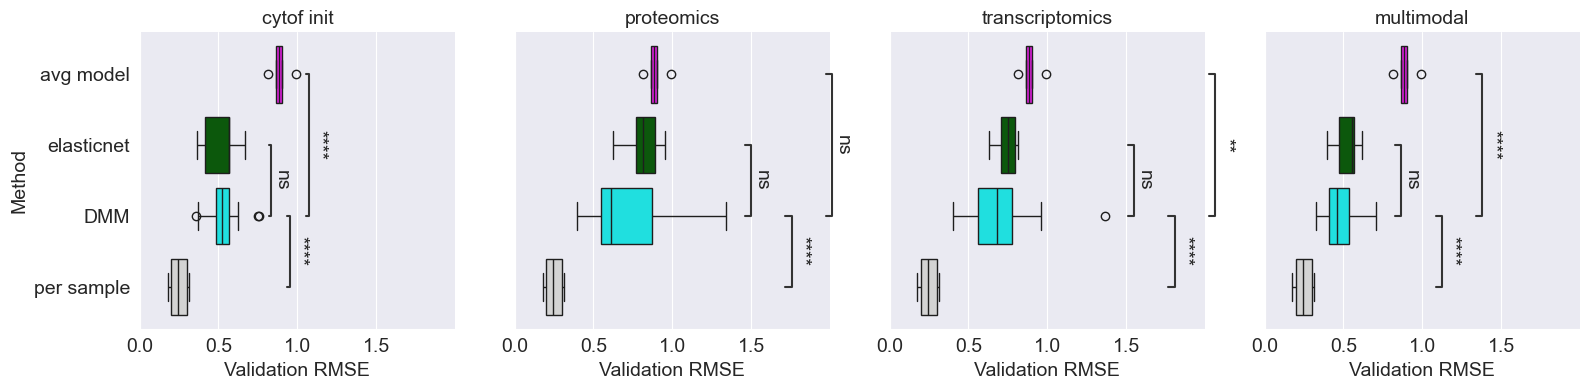

In [36]:
# Imports
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator

# --- tidy labels ---
ref_map = {
    "avg_model": "avg model",
    "sample": "per sample",
    # keep others as-is
}
context_map = {
    "cytof_init": "cytof init",
    # others unchanged
}

method_order = ["avg model", "elasticnet", "DMM", "per sample"]
context_order = ["cytof init", "proteomics", "transcriptomics", "multimodal"]

palette = {
    "avg model": "fuchsia",
    "per sample": "lightgray",
    "DMM": "cyan",
    "elasticnet": "darkgreen",
}

# --- prep data with display columns ---
plot_df = reduced_val_df.copy()
plot_df["ref_display"] = plot_df["ref"].replace(ref_map)
plot_df["context_display"] = plot_df["context"].replace(context_map)

# Keep only contexts we’ll facet on (and in this order)
plot_df = plot_df[plot_df["context_display"].isin(context_order)]

# --- build the FacetGrid ---
g = sns.FacetGrid(
    plot_df,
    col="context_display",
    col_order=context_order,
    height=4,
    aspect=1,
    sharex=True,
    sharey=True,
)

# We'll draw & annotate each facet manually so statannotations can use the right ax/data
for ctx, ax in zip(context_order, g.axes.flat):
    df_ctx = plot_df[plot_df["context_display"] == ctx]

    # Horizontal boxplot (rmse on x, methods on y)
    sns.boxplot(
        data=df_ctx,
        y="ref_display",
        x="rmse",
        order=method_order,
        palette=palette,
        ax=ax,
    )

    # --- per-facet comparisons: DMM vs others present in this facet ---
    requested = [("DMM", "elasticnet"),
                 ("DMM", "avg model"),
                 ("DMM", "per sample")]
    present = set(df_ctx["ref_display"].unique())
    comparisons = [(a, b) for (a, b) in requested if a in present and b in present]

    if comparisons:
        annot = Annotator(
            ax, comparisons,
            data=df_ctx,
            x="rmse", y="ref_display",
            order=method_order,
            orient="h"   # crucial for horizontal layout
        )
        annot.configure(
            test="Mann-Whitney", text_format="star", comparisons_correction="bonferroni",
            loc="inside", line_offset=0.01, line_height=0.02, fontsize=14,
            show_test_name=True
        )
        annot.apply_and_annotate()
    else:
        ax.text(0.02, 0.02, "No valid comparisons", transform=ax.transAxes, fontsize=9)

    # axis cosmetics per facet
    ax.set_xlim(0, 2.00)
    ax.set_xlabel("Validation RMSE", fontsize=14)
    ax.set_ylabel("Method", fontsize=14)
    ax.set_xticks([0, 0.50, 1.00, 1.50])
    sns.despine(ax=ax, left=False, bottom=False)
    ax.tick_params(axis="both", which="major", labelsize=14)

# Clean column titles (they already are display labels)
g.set_titles(col_template="{col_name}", size=14)

plt.tight_layout()
plt.savefig("base_fig1a_all_contexts_with_stats_fixedfont.svg", bbox_inches="tight")

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

elasticnet vs. DMM: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.000e+00 U_stat=1.590e+02
DMM vs. per sample: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.048e-02 U_stat=2.190e+02
avg model vs. DMM: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.035e-04 U_stat=2.420e+02
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

elasticnet vs. DMM: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:5.975e-01 U_stat=1.700e+02
DMM vs. per sample: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:2.587e-04 U_stat=2.390e+02
avg model vs. DMM: Mann-Whi

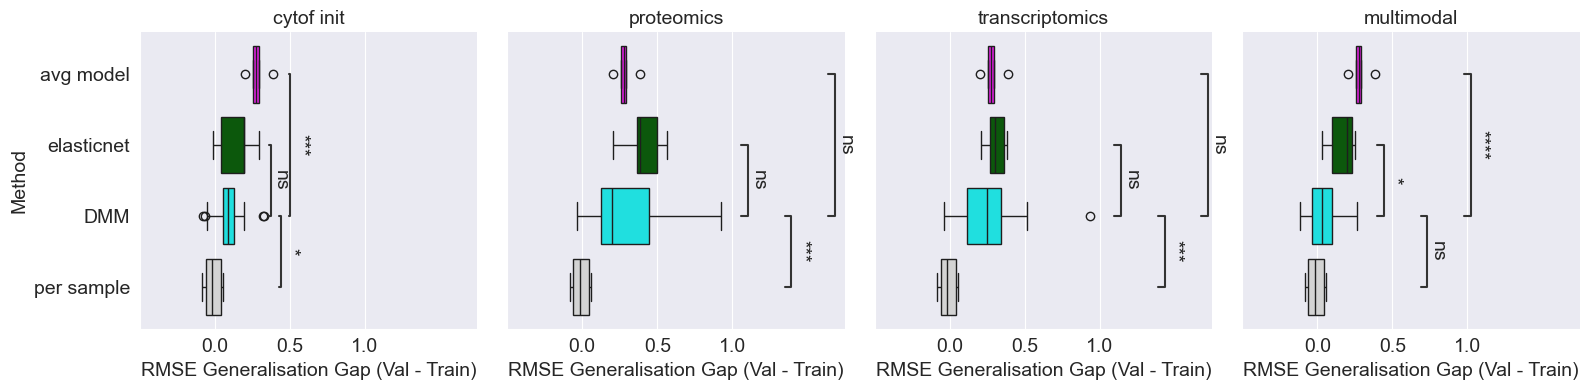

In [37]:
# Imports
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator

# --- tidy labels ---
ref_map = {
    "avg_model": "avg model",
    "sample": "per sample",
    # keep others as-is
}
context_map = {
    "cytof_init": "cytof init",
    # others unchanged
}

method_order = ["avg model", "elasticnet", "DMM", "per sample"]
context_order = ["cytof init", "proteomics", "transcriptomics", "multimodal"]

palette = {
    "avg model": "fuchsia",
    "per sample": "lightgray",
    "DMM": "cyan",
    "elasticnet": "darkgreen",
}

# --- prep data with display columns ---
plot_df_gap = reduced_gen_gap_df.copy()
plot_df_gap["ref_display"] = plot_df_gap["ref"].replace(ref_map)
plot_df_gap["context_display"] = plot_df_gap["context"].replace(context_map)

# Keep only contexts we’ll facet on (and in this order)
plot_df_gap = plot_df_gap[plot_df_gap["context_display"].isin(context_order)]

# --- build the FacetGrid ---
g = sns.FacetGrid(
    plot_df_gap,
    col="context_display",
    col_order=context_order,
    height=4,
    aspect=1,
    sharex=True,
    sharey=True,
)

# We'll draw & annotate each facet manually so statannotations can use the right ax/data
for ctx, ax in zip(context_order, g.axes.flat):
    df_ctx = plot_df_gap[plot_df_gap["context_display"] == ctx]

    # Horizontal boxplot (rmse on x, methods on y)
    sns.boxplot(
        data=df_ctx,
        y="ref_display",
        x="generalisation_gap",
        order=method_order,
        palette=palette,
        ax=ax,
    )

    # --- per-facet comparisons: DMM vs others present in this facet ---
    requested = [("DMM", "elasticnet"),
                 ("DMM", "avg model"),
                 ("DMM", "per sample"),]
    present = set(df_ctx["ref_display"].unique())
    comparisons = [(a, b) for (a, b) in requested if a in present and b in present]

    if comparisons:
        annot = Annotator(
            ax, comparisons,
            data=df_ctx,
            x="generalisation_gap", y="ref_display",
            order=method_order,
            orient="h"   # crucial for horizontal layout
        )
        annot.configure(
            test="Mann-Whitney", text_format="star", comparisons_correction="bonferroni",
            loc="inside", line_offset=0.02, line_height=0.02, fontsize=14,
            show_test_name=True
        )
        annot.apply_and_annotate()
    else:
        ax.text(0.02, 0.02, "No valid comparisons", transform=ax.transAxes, fontsize=9)

    # axis cosmetics per facet
    ax.set_xlim(-0.5, 1.75)
    ax.set_xlabel("RMSE Generalisation Gap (Val - Train)", fontsize=14)
    ax.set_ylabel("Method", fontsize=14)
    ax.set_xticks([0, 0.5, 1.00])
    sns.despine(ax=ax, left=False, bottom=False)
    ax.tick_params(axis="both", which="major", labelsize=14)

# Clean column titles (they already are display labels)
g.set_titles(col_template="{col_name}", size=14)

plt.tight_layout()
plt.savefig("base_fig1a_gengap_all_contexts_with_stats_fixedfont.svg", bbox_inches="tight")

5 5
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

elasticnet vs. DMM: Custom statistical test, P_val:5.476e-01
5 5
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

elasticnet vs. DMM: Custom statistical test, P_val:4.206e-01
5 5
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

elasticnet vs. DMM: Custom statistical test, P_val:3.095e-01
5 5
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

elasticnet vs. DMM: Custom statis

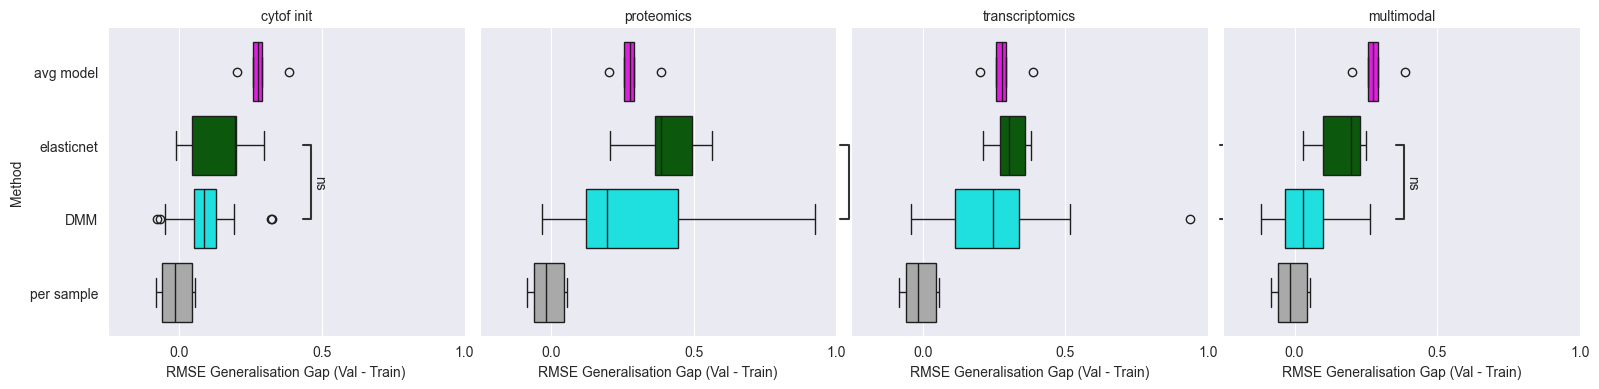

In [67]:
from statannotations.Annotator import Annotator
from scipy.stats import mannwhitneyu
import numpy as np

# Replace ref labels for plotting
label_map = {
    "avg_model": "avg model",
    "sample": "per sample",
    "DMM": "DMM",
    "elasticnet": "elasticnet"
}
context_map = {
    "cytof_init": "cytof init",
    "proteomics": "proteomics",
    "transcriptomics": "transcriptomics",
    "multimodal": "multimodal"
}
plot_df = reduced_gen_gap_df.replace({"ref": label_map})
plot_df = plot_df.replace({"context": context_map})

g = sns.FacetGrid(
    plot_df,
    col="context",
    col_order=["cytof init", "proteomics", "transcriptomics", "multimodal"],
    height=4,
    aspect=1,
)

g.map_dataframe(
    sns.boxplot,
    y="ref",
    x="generalisation_gap",
    order=["avg model", "elasticnet", "DMM", "per sample"],
    hue="ref",
    palette={
        "avg model": "fuchsia",
        "per sample": "darkgray",
        "DMM": "cyan",
        "elasticnet": "darkgreen",
    },
    hue_order=["avg model", "elasticnet", "DMM", "per sample"],
)

# Axis labels
g.set_axis_labels("RMSE Generalisation Gap (Val - Train)", "Method")

# Remove the "context = " prefix from column titles
g.set_titles(col_template="{col_name}")

plt.xlim([0, 1.5])
plt.xticks([0, 0.50, 1.00, 1.50])

# --- annotate DMM vs elasticnet inside each facet ---
y_order_full = ["avg model", "elasticnet", "DMM", "sample"]
pair = [("DMM", "elasticnet")]  # single comparison per facet

# Optional: collect raw p-values across facets to do a correction if desired
contexts_in_plot = ["cytof init", "proteomics", "transcriptomics", "multimodal"]
pvals_by_context = {}

for ax, ctx in zip(g.axes.flat, contexts_in_plot):
    # Subset data for this facet
    sub = plot_df[plot_df["context"] == ctx].copy()

    # Skip if either group missing
    if not {"DMM", "elasticnet"}.issubset(set(sub["ref"].unique())):
        continue

    # Order present in this facet (trim to avoid errors)
    y_order = [lbl for lbl in y_order_full if lbl in sub["ref"].unique()]

    # Compute MWU p-value (two-sided)
    a = sub.loc[sub["ref"] == "DMM", ["samples", "generalisation_gap", "job"]].sort_values(by="samples").groupby("samples").generalisation_gap.mean().to_numpy()
    b = sub.loc[sub["ref"] == "elasticnet", ["samples", "generalisation_gap"]].sort_values(by="samples").generalisation_gap.to_numpy()
    print(len(a), len(b))
    a = a[~np.isnan(a)]
    b = b[~np.isnan(b)]
    if len(a) == 0 or len(b) == 0:
        continue
    _, pval = mannwhitneyu(a, b, alternative="two-sided")
    pvals_by_context[ctx] = pval

    # Annotate on this axis
    annot = Annotator(
        ax, pair, data=sub,
        x="generalisation_gap", y="ref",
        order=y_order,
        orient='h'
    )
    # use precomputed p-value so it's consistent with what we report
    annot.set_pvalues_and_annotate([pval])

# Remove the "context = " prefix from column titles
g.set_titles(col_template="{col_name}")

plt.xlim([-0.25, 1.00])
plt.xticks([0, 0.50, 1.00])
plt.savefig("base_fig1a_all_contexts_gengap_v3_stattests.svg")

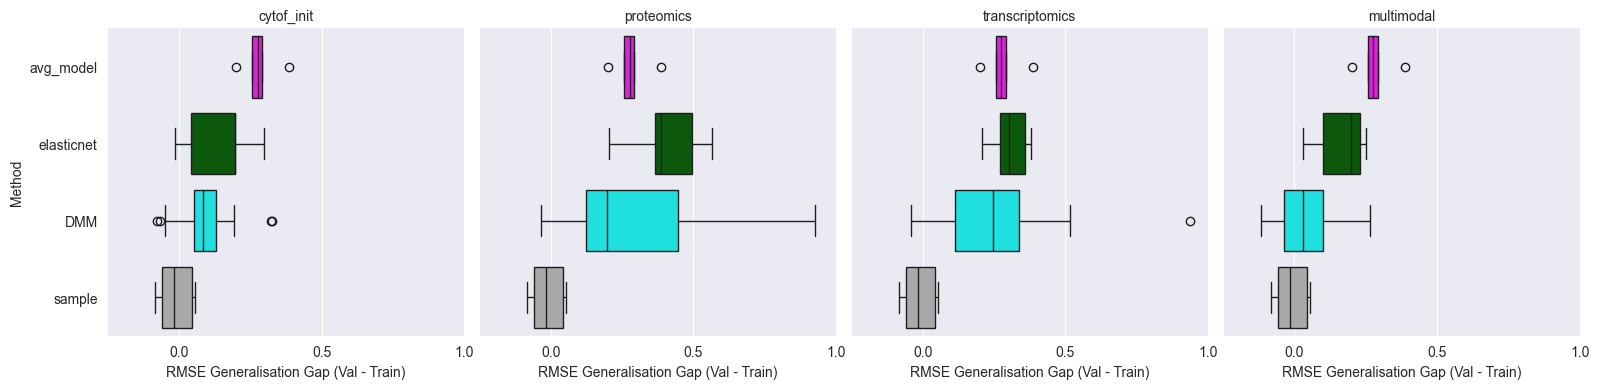

In [66]:
g = sns.FacetGrid(
    reduced_gen_gap_df,
    col="context",
    col_order=["cytof_init", "proteomics", "transcriptomics", "multimodal"],
    height=4,
    aspect=1,
)

g.map_dataframe(
    sns.boxplot,
    y="ref",
    x="generalisation_gap",
    order=["avg_model", "elasticnet", "DMM", "sample"],
    hue="ref",
    palette={
        "avg_model": "fuchsia",
        "sample": "darkgray",
        "DMM": "cyan",
        "elasticnet": "darkgreen",
    },
    hue_order=["avg_model", "elasticnet", "DMM", "sample"],
)

# Axis labels
g.set_axis_labels("RMSE Generalisation Gap (Val - Train)", "Method")

# Remove the "context = " prefix from column titles
g.set_titles(col_template="{col_name}")

plt.xlim([-0.25, 1.00])
plt.xticks([0, 0.50, 1.00])

plt.savefig("base_fig1a_all_contexts_gengap_v3.svg")

# Per CV split plot

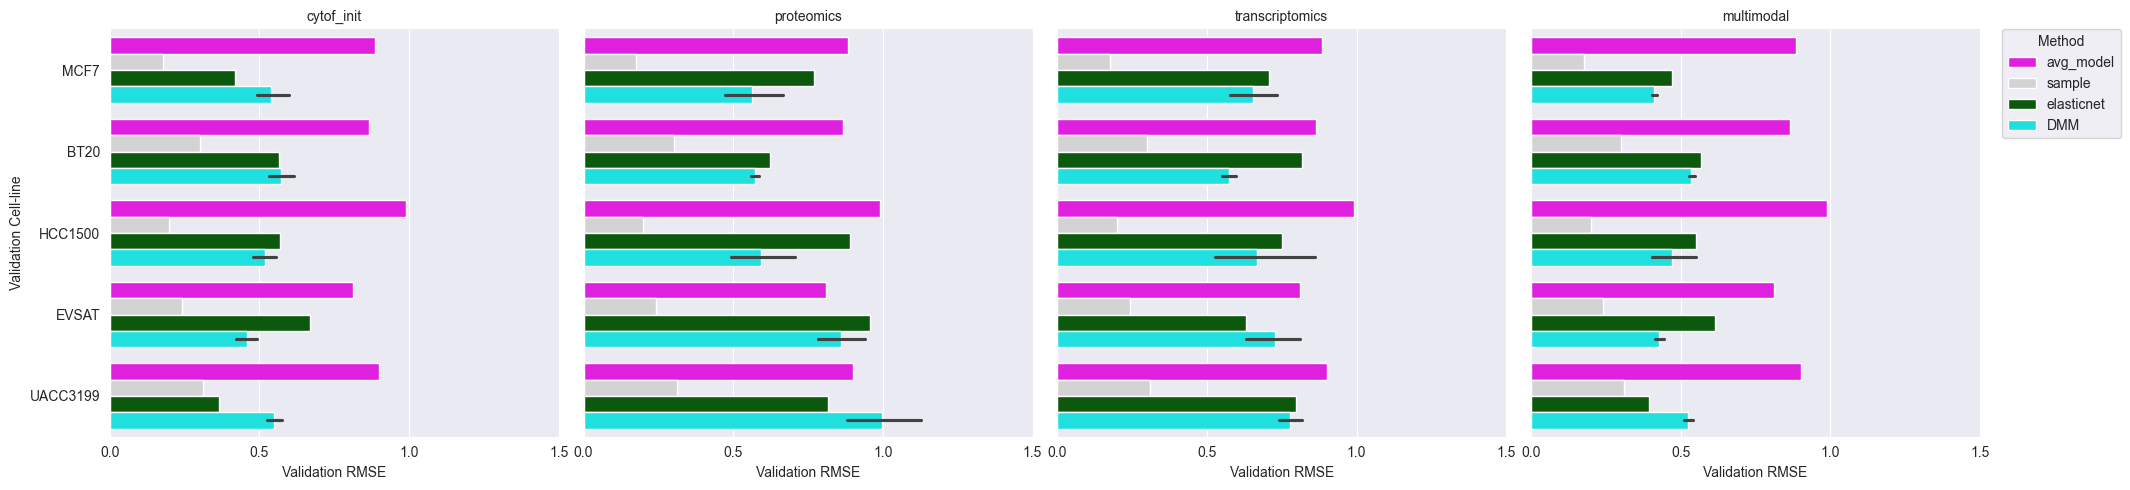

In [24]:
ref_palette = {
        "avg_model": "fuchsia",
        "sample": "lightgray",
        "DMM": "cyan",
        "elasticnet": "darkgreen",
    }
g = sns.FacetGrid(
    reduced_val_df,
    col="context",
    col_order=["cytof_init", "proteomics", "transcriptomics", "multimodal"],
    height=5,
)

g.map_dataframe(
    sns.barplot,
    y="samples",
    x="rmse",
    hue="ref",
    order=["MCF7", "BT20", "HCC1500", "EVSAT", "UACC3199"],
    palette=ref_palette,
    hue_order=["avg_model", "sample", "elasticnet", "DMM"]
)
# Axis labels
g.set_axis_labels("Validation RMSE", "Validation Cell-line")

# Remove the "context = " prefix from column titles
g.set_titles(col_template="{col_name}")

plt.xlim([0, 1.5])
plt.xticks([0, 0.50, 1.00, 1.50])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., title="Method")

plt.savefig("base_fig1a_all_contexts_samplesplit_v3.svg")

In [25]:
val_df.groupby(["context", "features", "ref", "samples"]).rmse.mean()

context          features  ref        samples 
cytof_init       None      avg_model  BT20        0.865491
                                      EVSAT       0.811184
                                      HCC1500     0.990033
                                      MCF7        0.884996
                                      UACC3199    0.900677
                                                    ...   
transcriptomics  None      sample     BT20        0.301176
                                      EVSAT       0.242057
                                      HCC1500     0.199262
                                      MCF7        0.176687
                                      UACC3199    0.311391
Name: rmse, Length: 140, dtype: float64

# Looking at best performing model (`multimodal`): is it statistically significantly better than the regressors? No.

In [26]:
val_df[
        val_df.ref.isin(["DMM"])
        & val_df.model.isin(["EGFR_MAPK__logobs",])
        & (val_df.context == "multimodal")
        & (val_df.features == "best_RFE_10_permute")
    ].sort_values(
        by=["context", "samples", "job"]
    ).groupby(["context", "samples"]).rmse.mean()

context     samples 
multimodal  BT20        0.536252
            EVSAT       0.429186
            HCC1500     0.470611
            MCF7        0.411245
            UACC3199    0.525742
Name: rmse, dtype: float64

In [31]:
val_df[
        val_df.ref.isin(["elasticnet"])
        & (val_df.context == "multimodal")
        & (val_df.features == "best_RFE_10_permute")
    ].sort_values(
        by=["context", "samples", "job"]
    )[["samples", "rmse"]]

,samples,rmse
165,BT20,0.566790
168,EVSAT,0.615871
171,HCC1500,0.552332
174,MCF7,0.471146
177,UACC3199,0.395423


In [34]:
from scipy import stats

groups = [
    val_df[
        val_df.ref.isin(["DMM"])
        & (val_df.context == "multimodal")
        & (val_df.features == "best_RFE_10_permute")
    ].sort_values(
        by=["context", "samples", "job"]
    ).groupby(["context", "samples"]).rmse.mean().values,
    val_df[
        val_df.ref.isin(["elasticnet"])
        & (val_df.context == "multimodal")
        & (val_df.features == "best_RFE_10_permute")
    ].sort_values(
        by=["context", "samples", "job"]
    ).rmse.values,
]
stat, p = stats.wilcoxon(*groups, alternative="two-sided")
print(f"Wilcoxon signed-rank: W={stat}, p={p:.4g}")

Wilcoxon signed-rank: W=4.0, p=0.4375
